# Aprendizaje no-Supervisado: PCA, Selección de Variables y K-Means

Este proyecto explora técnicas de reducción de dimensionalidad y agrupamiento utilizando el dataset de calidad de vino.

## 1. Carga de Datos y Configuración

In [30]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Descarga del dataset utilizando la API de kagglehub
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

# 2. Carga del archivo CSV en un DataFrame de pandas
df = pd.read_csv(f"{path}/WineQT.csv")

# 3. Limpieza de datos: eliminamos la columna 'Id' ya que no aporta información relevante para el modelado
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Estandarización y PCA

Antes de aplicar PCA, estandarizamos los datos.

In [31]:
X = df.drop(columns=['quality'])
y = df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

## 3. Scree-Plot

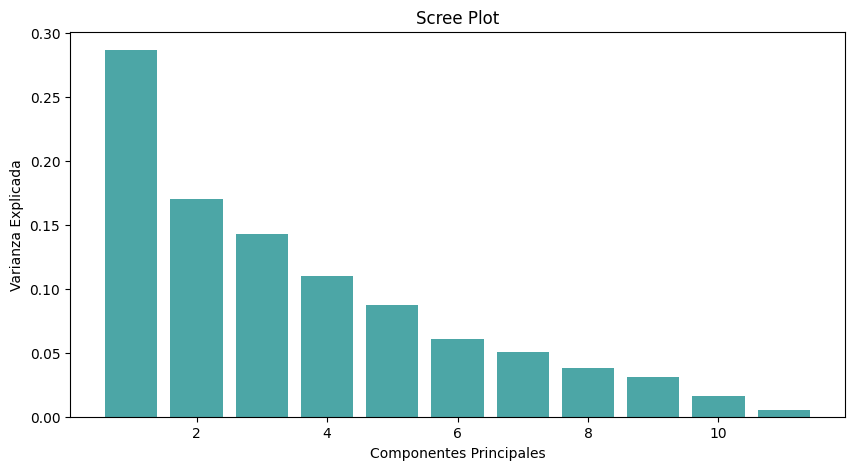

In [32]:
explained_variance = pca_full.explained_variance_ratio_
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='teal')
plt.xlabel('Componentes Principales')
plt.ylabel('Varianza Explicada')
plt.title('Scree Plot')
plt.show()

### Análisis del Scree Plot
Basado en el gráfico anterior:
- La primera componente (PC1) explica aproximadamente el **29%** de la varianza.
- La segunda componente (PC2) aporta un **17%** adicional.
- En conjunto, las dos primeras componentes capturan el **46% de la información total**, lo que justifica su uso para la reducción a 2D.

## 4. Reducción a 2 Componentes Principales

In [33]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

## 5. Visualización de las 2 Componentes

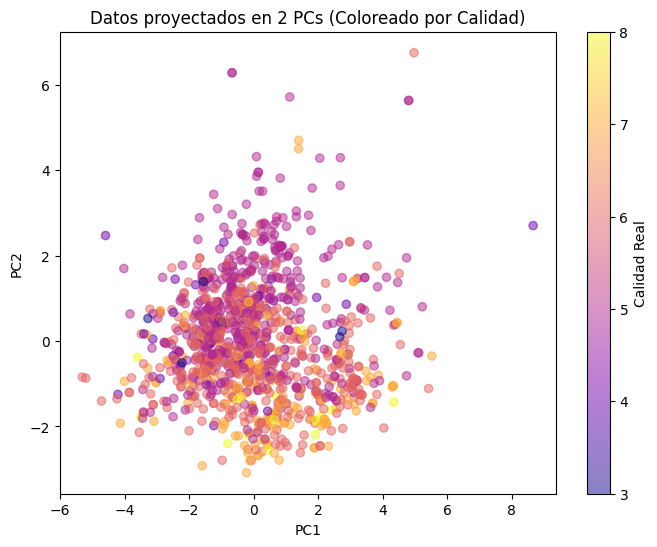

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap='plasma', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Datos proyectados en 2 PCs (Coloreado por Calidad)')
plt.colorbar(label='Calidad Real')
plt.show()

## 6. Selección de Variables (Top 5)

In [35]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
selected_features = importances.head(5).index.tolist()
X_selected = scaler.fit_transform(df[selected_features])

print(f"Variables seleccionadas: {selected_features}")

Variables seleccionadas: ['alcohol', 'sulphates', 'volatile acidity', 'total sulfur dioxide', 'pH']


## 7. Agrupamiento con K-Means

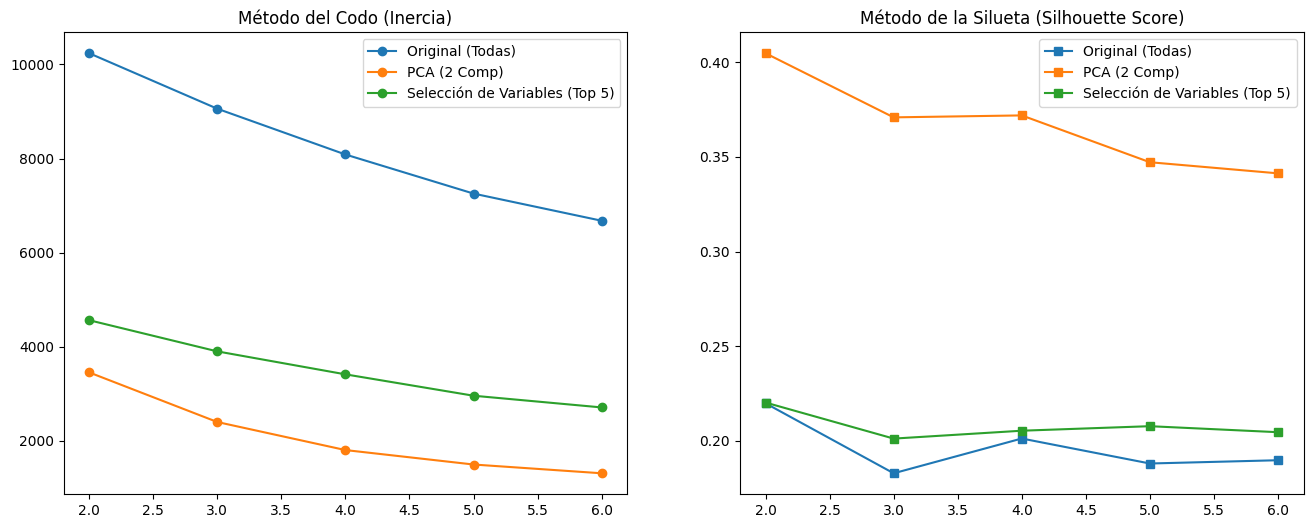

In [ ]:
datasets = {
    'Original (Todas)': X_scaled,
    'PCA (2 Comp)': X_pca_2,
    'Selección de Variables (Top 5)': X_selected
}

k_range = range(2, 7)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, data in datasets.items():
    inertias = []
    silhouettes = []
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(data)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(data, kmeans.labels_))
    
    axes[0].plot(k_range, inertias, marker='o', label=label)
    axes[1].plot(k_range, silhouettes, marker='s', label=label)

axes[0].set_title('Método del Codo (Inercia)')
axes[1].set_title('Método de la Silueta (Silhouette Score)')
axes[0].legend()
axes[1].legend()
plt.show()

### Visualización de Clústeres (K=2 sobre PCA)
Observamos cómo K-means agrupa los datos en el espacio reducido.

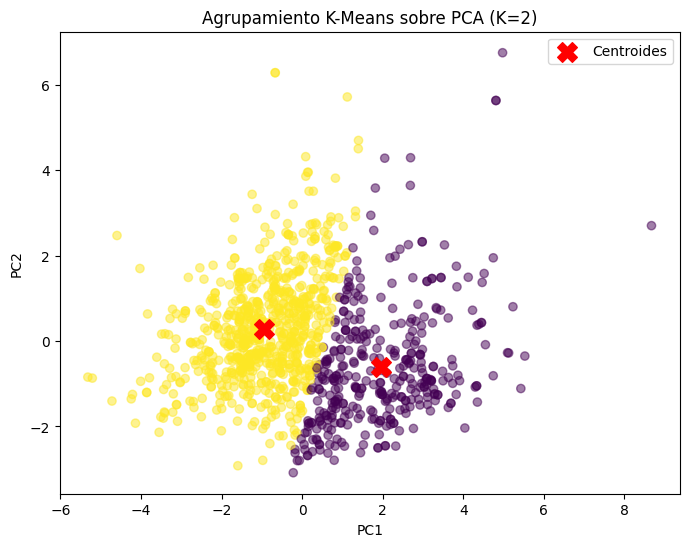

In [37]:
kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca_2)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=clusters_pca, cmap='viridis', alpha=0.5)
plt.scatter(kmeans_pca.cluster_centers_[:, 0], kmeans_pca.cluster_centers_[:, 1], 
            s=200, c='red', marker='X', label='Centroides')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Agrupamiento K-Means sobre PCA (K=2)')
plt.legend()
plt.show()

### Análisis de Agrupamiento
Al evaluar K-Means sobre las tres versiones:
- **Método del Codo**: La inercia disminuye más rápido en la versión de PCA, indicando clústeres más eficientes. El dataset original presenta inercias muy altas (~10,000).
- **Método de la Silueta**: PCA es el ganador absoluto con un score de **~0.40 para K=2**. Esto es casi el doble del rendimiento obtenido con el dataset original (~0.22), lo que demuestra que PCA eliminó dimensiones que generaban ruido.

### Análisis del Agrupamiento (K=2 sobre PCA):
- **Separación de Grupos**: A pesar de que los datos originales son complejos, K-means ha logrado identificar dos perfiles bien diferenciados en el espacio reducido. La frontera entre el clúster amarillo y el morado es clara, lo que valida el uso de K=2.
- **Rol de los Centroides:** Los centroides (cruces rojas) están bien centrados en sus respectivas nubes de puntos, lo que indica que el algoritmo convergió de manera estable.
- **Influencia de PC1:** La separación ocurre principalmente a lo largo del eje PC1. Esto significa que las variables que más contribuyen a PC1 (posiblemente el alcohol y la acidez volátil) son las que realmente están dividiendo a los vinos en estos dos grupos.

## 8. Comparación de Resultados

**Análisis de los Enfoques:**

1. **Dataset Original**: Presenta la mayor inercia y los Silhouette Scores más bajos (~0.20). Esto indica que la alta dimensionalidad y el ruido dificultan la formación de clústeres compactos.
2. **Reducción por PCA**: Es el enfoque más exitoso. Logra un Silhouette Score significativamente más alto (~0.40 para K=2), lo que demuestra que al proyectar los datos en direcciones de máxima varianza se eliminan dimensiones irrelevantes que confundían al algoritmo.
3. **Selección de Variables**: Ofrece resultados intermedios. Aunque mejora ligeramente la cohesión respecto al original, no alcanza la claridad geométrica que proporciona la extracción de características por PCA.

**Conclusión sobre K:**
En todas las versiones, el valor de **K=2** ofrece la mejor separación métrica, sugiriendo una estructura binaria natural en los datos del vino.